In [1]:
import torch
from fastai.vision.all import *
print(torch.cuda.is_available()) 

True


In [2]:
path1 = Path(r'D:\Traffic\Indian-Traffic Sign-Dataset')

In [3]:
df = pd.read_csv(path1/'traffic_sign.csv')

In [4]:
index_list = [int((df['ClassId']).iloc[x]) for x in range(59)]
print(index_list)

paths = [Path(path1/'Images'/str(x)) for x in range(59)]
paths

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]


[Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/0'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/1'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/2'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/3'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/4'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/5'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/6'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/7'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/8'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/9'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/10'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/11'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/12'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/13'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/14'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/15'),
 Path('D:/Traffic/Indian-Traffic Sign-Dataset/Images/16'),
 Path('

In [5]:
labels_list = [(df['Name']).iloc[x] for x in range(59)]
labels_list

['Give way',
 'No entry',
 'One-way traffic',
 'One-way traffic',
 'No vehicles in both directions',
 'No entry for cycles',
 'No entry for goods vehicles',
 'No entry for pedestrians',
 'No entry for bullock carts',
 'No entry for hand carts',
 'No entry for motor vehicles',
 'Height limit',
 'Weight limit',
 'Axle weight limit',
 'Length limit',
 'No left turn',
 'No right turn',
 'No overtaking',
 'Maximum speed limit (90 km/h)',
 'Maximum speed limit (110 km/h)',
 'Horn prohibited',
 'No parking',
 'No stopping',
 'Turn left',
 'Turn right',
 'Steep descent',
 'Steep ascent',
 'Narrow road',
 'Narrow bridge',
 'Unprotected quay',
 'Road hump',
 'Dip',
 'Loose gravel',
 'Falling rocks',
 'Cattle',
 'Crossroads',
 'Side road junction',
 'Side road junction',
 'Oblique side road junction',
 'Oblique side road junction',
 'T-junction',
 'Y-junction',
 'Staggered side road junction',
 'Staggered side road junction',
 'Roundabout',
 'Guarded level crossing ahead',
 'Unguarded level cross

In [12]:
dblock = DataBlock(blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    get_y = lambda y: y.parent.name,
    splitter = RandomSplitter(seed = 42)
)

In [13]:
dsets = dblock.datasets(path1)

In [14]:
dsets.train[0]

(PILImage mode=RGB size=32x32, TensorCategory(3))

In [15]:
dsets.valid

(#2794) [(PILImage mode=RGB size=32x32, TensorCategory(13)), (PILImage mode=RGB size=32x32, TensorCategory(54)), (PILImage mode=RGB size=32x32, TensorCategory(40)), (PILImage mode=RGB size=32x32, TensorCategory(44)), (PILImage mode=RGB size=32x32, TensorCategory(10)), (PILImage mode=RGB size=32x32, TensorCategory(36)), (PILImage mode=RGB size=32x32, TensorCategory(48)), (PILImage mode=RGB size=32x32, TensorCategory(48)), (PILImage mode=RGB size=32x32, TensorCategory(48)), (PILImage mode=RGB size=32x32, TensorCategory(21)), (PILImage mode=RGB size=32x32, TensorCategory(13)), (PILImage mode=RGB size=32x32, TensorCategory(34)), (PILImage mode=RGB size=32x32, TensorCategory(27)), (PILImage mode=RGB size=32x32, TensorCategory(50)), (PILImage mode=RGB size=32x32, TensorCategory(8)), (PILImage mode=RGB size=32x32, TensorCategory(1)), (PILImage mode=RGB size=32x32, TensorCategory(48)), (PILImage mode=RGB size=32x32, TensorCategory(44)), (PILImage mode=RGB size=32x32, TensorCategory(40)), (PILI

In [16]:
dsets.train[0][1]

TensorCategory(3)

In [17]:
dsets.train[2]

(PILImage mode=RGB size=32x32, TensorCategory(48))

In [20]:
dls = dblock.dataloaders(path1)

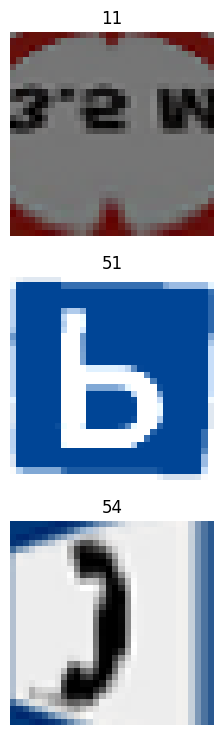

In [21]:
dls.show_batch(nrows = 3, ncols = 1)

In [23]:
dblock.summary(path1)

Setting-up type transforms pipelines
Found 13971 items
2 datasets of sizes 11177,2794
Setting up Pipeline: PILBase.create
Setting up Pipeline: <lambda> -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      D:\Traffic\Indian-Traffic Sign-Dataset\Images\11\11_original_54_original_54.png_a14e4655-1dc1-4bd7-9a13-b12e413008d0.png_224dc2c3-7339-4c98-bc1e-88c13ffe0775.png
    applying PILBase.create gives
      PILImage mode=RGB size=32x32
  Pipeline: <lambda> -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      D:\Traffic\Indian-Traffic Sign-Dataset\Images\11\11_original_54_original_54.png_a14e4655-1dc1-4bd7-9a13-b12e413008d0.png_224dc2c3-7339-4c98-bc1e-88c13ffe0775.png
    applying <lambda> gives
      11
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(3)

Final sample: (PILImage mode=RGB size=32x32, TensorCategory(3))



In [24]:
from fastprogress.fastprogress import master_bar, progress_bar
master_bar, progress_bar = master_bar, progress_bar

In [25]:
learn = vision_learner(dls, resnet34, metrics = error_rate) 

In [27]:
learn.fine_tune(2)

epoch,train_loss,valid_loss,error_rate,time
0,2.771558,1.679877,0.454545,02:49


epoch,train_loss,valid_loss,error_rate,time
0,1.300145,0.776094,0.243379,00:14
1,0.780792,0.574567,0.194345,00:14
